Run this first — it installs everything the lab needs.

In [ ]:
%pip install -q qiskit qiskit-aer pylatexenc matplotlib

# 20. Quantum Error Correction

## Objectives
* Build a **logical qubit** from several physical ones with the **3-qubit bit-flip code**, and measure a **syndrome** to find errors *without* collapsing the state you are protecting.
* Run your codes as **real Qiskit circuits under a noise model** — extracting the syndrome, **correcting the error live in the circuit**, and reading the logical error rate straight off the shots.
* Discover the **threshold**, find the bit-flip code's fatal **blind spot** (phase errors), and fix it with the **Steane [[7,1,3]] code**, which corrects *every* single-qubit error.

In **Lab 18** and **Lab 19** you *mitigated* noise: you left the errors in the machine and
cleaned up the **answer** afterward — with twirling, extrapolation, more shots. That buys
accuracy, but it never removes the error, and the cost explodes as circuits grow.

**Error _correction_ is the other road.** Instead of post-processing the answer, we make the
computation itself fault-tolerant: spread one *logical* qubit across many *physical* ones so
that when a few of them fail, the information survives. This is the idea behind every
roadmap to a large-scale quantum computer.

It is not free, and the trade-off should feel familiar from **Lab 9**: there you saw that a
*better-synthesized* gate can carry *more* hardware error. Here you'll meet the same tension —
more physical qubits mean more places to fail, and correction only pays off once the
hardware is good enough. You'll find exactly where that line sits by **building the circuits
and running them under realistic noise** — no shortcuts, no formulas you didn't earn.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

rng = np.random.default_rng(20)
sim = AerSimulator()

## 1. Errors, and the oldest trick for beating them

A physical qubit is fragile: stray fields, control imperfections and energy loss all nudge
it off course. Classically, we've handled unreliable hardware for decades with one humble
idea — **redundancy**. To send one bit safely over a noisy line, send it three times and
take a **majority vote**:

<p align="center">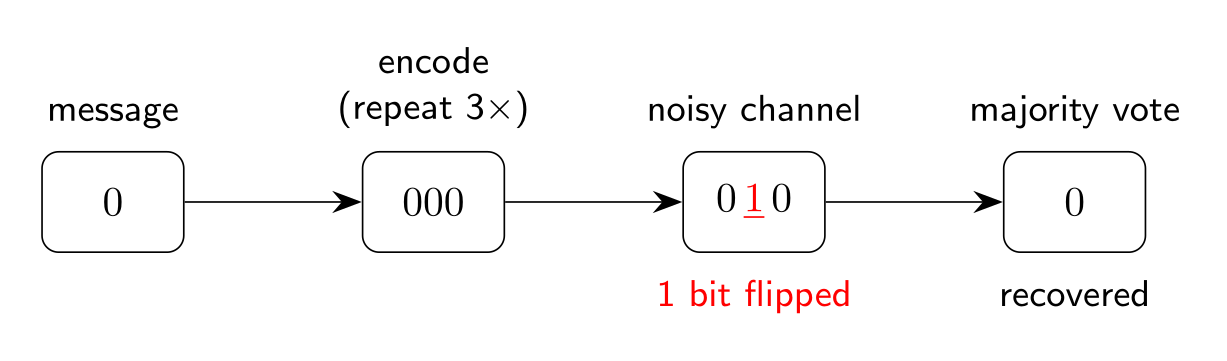</p>

A single flipped copy is outvoted, so the message survives. The vote is only fooled if **two
or more** of the three flip — and if each flips independently with probability $p$, that's
much rarer than $p$ whenever $p$ is small. That gap is what protection *is*.

Carrying this into the quantum world runs straight into three walls:

1. **No-cloning** — you cannot copy an unknown state $\alpha|0\rangle+\beta|1\rangle$, so
   "just send it three times" is off the table.
2. **Measurement collapses** — reading a qubit to check it destroys the superposition you
   were trying to protect.
3. **Errors are continuous** — a qubit can rotate by *any* small angle, not just flip.

Quantum error correction is the art of dodging all three. But the classical intuition still
guides us, so let's nail it down first.

<b>Warm-up: the classical majority vote.</b> Write <code>majority(bits)</code> that returns the
majority value (0 or 1) of a 1-D array of bits. Then a noisy round is provided for you: we
"send" the bit <code>0</code> as <code>000</code> over a channel that flips each copy with
probability $p=0.1$, and report how often the vote is wrong.

In [ ]:
def majority(bits):
    "Return the majority value (0/1) of a 1-D array of bits."
    # your code here
    ???

# provided: a noisy round over many messages
p, trials = 0.1, 100_000
flips = rng.random((trials, 3)) < p           # which of the 3 copies flipped
wrong = np.array([majority(row) for row in flips[:2000]])   # spot-check the fn
logical = (flips.sum(1) > 1.5).mean()         # vote wrong  <=>  >=2 copies flipped
print(f"physical error rate: {p}")
print(f"logical error rate after majority vote: {logical:.4f}")

## 2. Encoding a logical qubit

The quantum version of "repeat three times" is the **3-qubit bit-flip code**. We don't copy
the state — we *entangle* it across three qubits with two CNOTs:

$$\alpha|0\rangle + \beta|1\rangle \;\longmapsto\; \alpha|000\rangle + \beta|111\rangle .$$

This sidesteps no-cloning: the result is **not** three copies. Feed in $|+\rangle$ and you get
the GHZ state $\tfrac{1}{\sqrt2}(|000\rangle+|111\rangle)$, an entangled whole — not
$|{+}{+}{+}\rangle$. We call $|000\rangle$ and $|111\rangle$ the **logical** states
$|0\rangle_L$ and $|1\rangle_L$.

<b>Build the encoder.</b> Complete <code>encode_bitflip(qc)</code> so that, with the qubit to
protect on wire 0, it produces $\alpha|000\rangle+\beta|111\rangle$. Two CNOTs do it. The cell
then prepares a test input $\cos\tfrac{\theta}{2}|0\rangle+\sin\tfrac{\theta}{2}|1\rangle$ on
wire 0 and checks the encoded state has amplitude only on $|000\rangle$ and $|111\rangle$.

In [ ]:
def encode_bitflip(qc):
    "Encode the logical qubit on wire 0 into wires 0,1,2."
    # your code here
    ???

# verify on an arbitrary input state
theta = 1.0
qc = QuantumCircuit(3)
qc.ry(theta, 0)
encode_bitflip(qc)
amp = Statevector(qc).data
print(f"amplitude on |000>: {amp[0].real:.3f}   (expect cos = {np.cos(theta/2):.3f})")
print(f"amplitude on |111>: {amp[7].real:.3f}   (expect sin = {np.sin(theta/2):.3f})")
print(f"leakage onto other states: {np.abs(amp[[1,2,3,4,5,6]]).sum():.1e}")

Take a look at the circuit you just built — one qubit fanning out into three.

In [ ]:
qc = QuantumCircuit(3)
qc.ry(1.0, 0)
encode_bitflip(qc)
qc.draw("mpl")

**✓ Check your circuit.** The `Ry` is the test input on wire 0; after it, your two CNOTs should fan wire 0 out onto wires 1 and 2. Yours should match this:

<p align="center">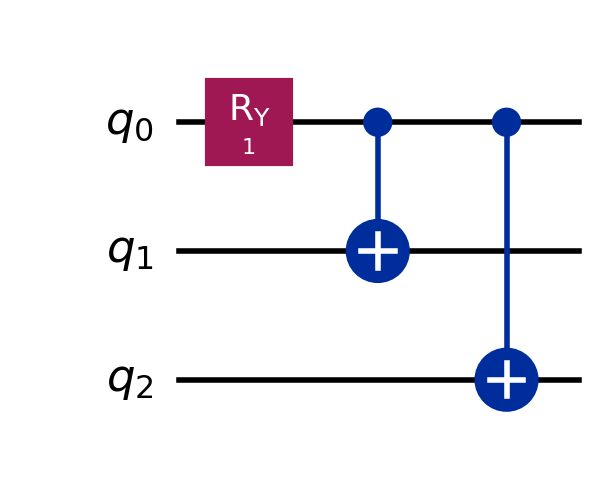</p>

## 3. Detecting errors without looking

Here's the catch from wall #2: if we *measure* the three qubits to see whether they still
agree, we collapse the superposition and destroy the logical state. The escape is to measure
a **parity**, not a qubit — a question whose answer reveals an *error* while telling us
*nothing* about $\alpha$ and $\beta$.

We use two parity checks, read out onto two **ancilla** qubits:

<p align="center">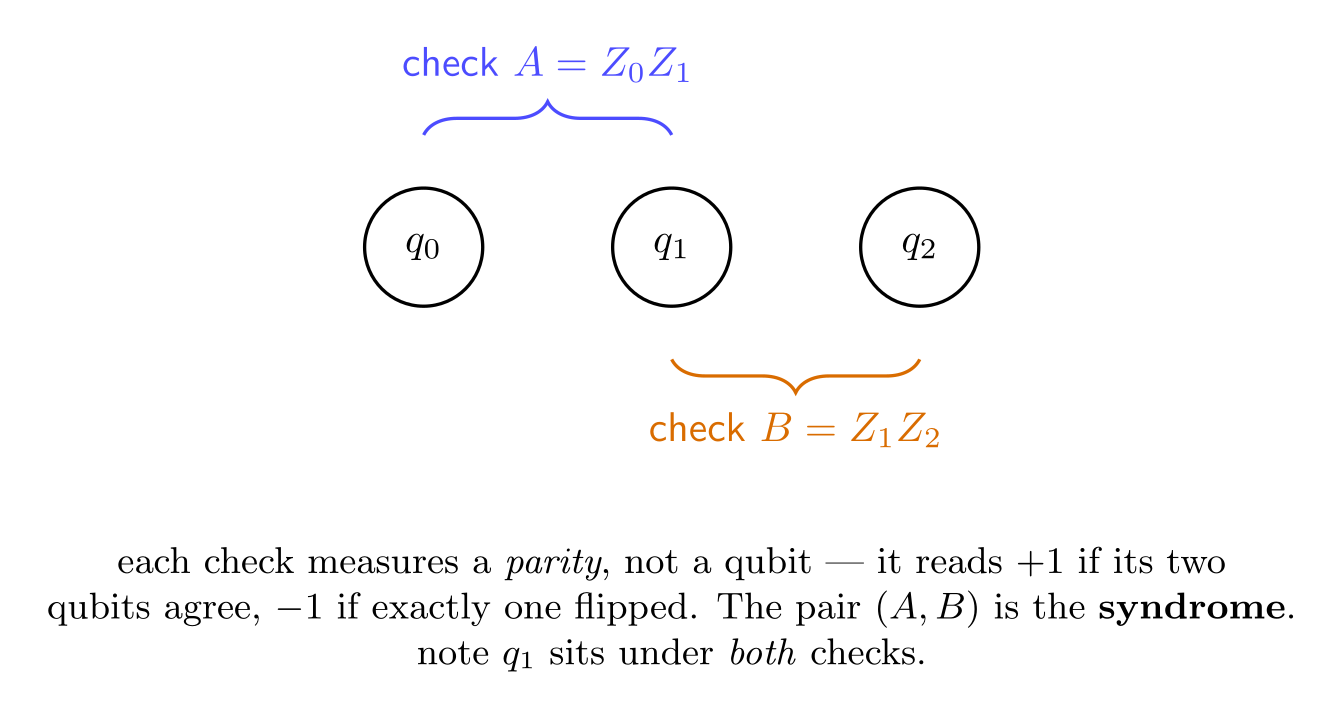</p>

Check $A=Z_0Z_1$ asks "do qubits 0 and 1 agree?"; check $B=Z_1Z_2$ asks the same of 1 and 2.
A single CNOT from each data qubit onto an ancilla accumulates that parity. The pair of
answers $(A,B)$ is the **syndrome**. Crucially, both $|000\rangle$ and $|111\rangle$ give
syndrome $(0,0)$ — so the checks are blind to *which* logical state we hold, and a
superposition sails through untouched.

<b>Build the syndrome extractor.</b> Inside <code>build_syndrome</code>, after the (optional)
injected error, write the two parity checks. Each ancilla starts in $|0\rangle$, so a CNOT
from a data qubit onto it simply XORs that bit in — two CNOTs accumulate a parity. Add, in order:

1. Check $A = Z_0 Z_1$ &rarr; ancilla&nbsp;3: a CNOT from data qubit&nbsp;0 onto qubit&nbsp;3, then a CNOT from data qubit&nbsp;1 onto qubit&nbsp;3.
2. Check $B = Z_1 Z_2$ &rarr; ancilla&nbsp;4: a CNOT from data qubit&nbsp;1 onto qubit&nbsp;4, then a CNOT from data qubit&nbsp;2 onto qubit&nbsp;4.

The two measurements onto the classical bits are already provided. The harness runs your circuit
on a known bit-flip and returns $(A,B)$ — so you can fill in the table yourself.

In [ ]:
def build_syndrome(error_qubit=None):
    "Build the syndrome-extraction circuit (with an optional injected X error)."
    qc = QuantumCircuit(5, 2)        # data: 0,1,2   ancillas: 3,4
    if error_qubit is not None:
        qc.x(error_qubit)            # a bit-flip strikes |0>_L = |000>
    # your code here
    ???
    qc.measure(3, 0); qc.measure(4, 1)
    return qc

def get_syndrome(error_qubit):       # provided: run the circuit, read out (A, B)
    bits = list(sim.run(build_syndrome(error_qubit), shots=1).result().get_counts())[0]
    B, A = int(bits[0]), int(bits[1])
    return (A, B)

for ej in [None, 0, 1, 2]:
    where = "no error" if ej is None else f"X on qubit {ej}"
    print(f"{where:12s} -> syndrome (A, B) = {get_syndrome(ej)}")

<b>Look at the circuit you built.</b> Here it is with an $X$ error injected on qubit 1 —
trace how the two CNOTs funnel each parity onto its ancilla, which is then measured. The two
data-ancilla "combs" *are* the checks $A$ and $B$.

In [ ]:
build_syndrome(1).draw("mpl")

**✓ Check your circuit.** With the injected $X$ on qubit 1: the first comb (onto ancilla 3) reads $Z_0Z_1$, the second (onto ancilla 4) reads $Z_1Z_2$, then both ancillas are measured. Yours should match this:

<p align="center">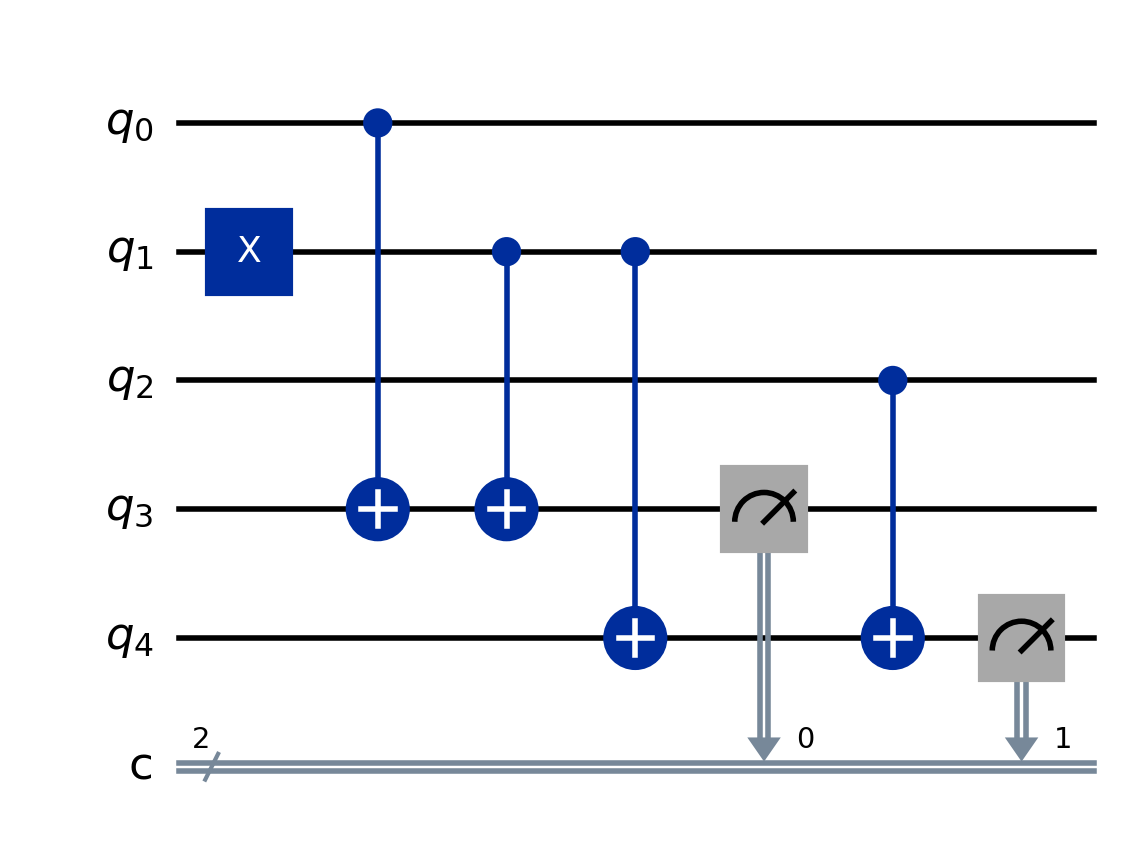</p>

Read off your table. Each single-qubit error produces a **different** syndrome, and
$(0,0)$ means "no error detected":

| syndrome $(A,B)$ | meaning | correction |
|:---:|:---|:---|
| $(0,0)$ | no error | do nothing |
| $(1,0)$ | qubit 0 flipped | apply $X_0$ |
| $(1,1)$ | qubit 1 flipped | apply $X_1$ |
| $(0,1)$ | qubit 2 flipped | apply $X_2$ |

That last column is the **decoder**: a map from syndrome to the recovery operation. Apply it
and the logical state is restored — and because the syndrome never referenced $\alpha,\beta$,
it works for an *arbitrary* encoded state, superposition and all. In the next section you'll
wire this correction **into the circuit** and let a noise model — not a formula — tell you how
well it works.

### Aside — decoding is a research field of its own

For three qubits the decoder is a four-row table. But a real code has *many* checks, and the
map from syndrome to best correction gets hard fast. The naive "store every syndrome in a
lookup table" needs $2^{\,n-k}$ entries for an $n$-qubit code carrying $k$ logical qubits —
which is exact, but blows up exponentially. Bigger codes demand cleverer **decoders**, and
they trade off along three axes: **accuracy**, **speed/latency**, and **scalability**.

<p align="center">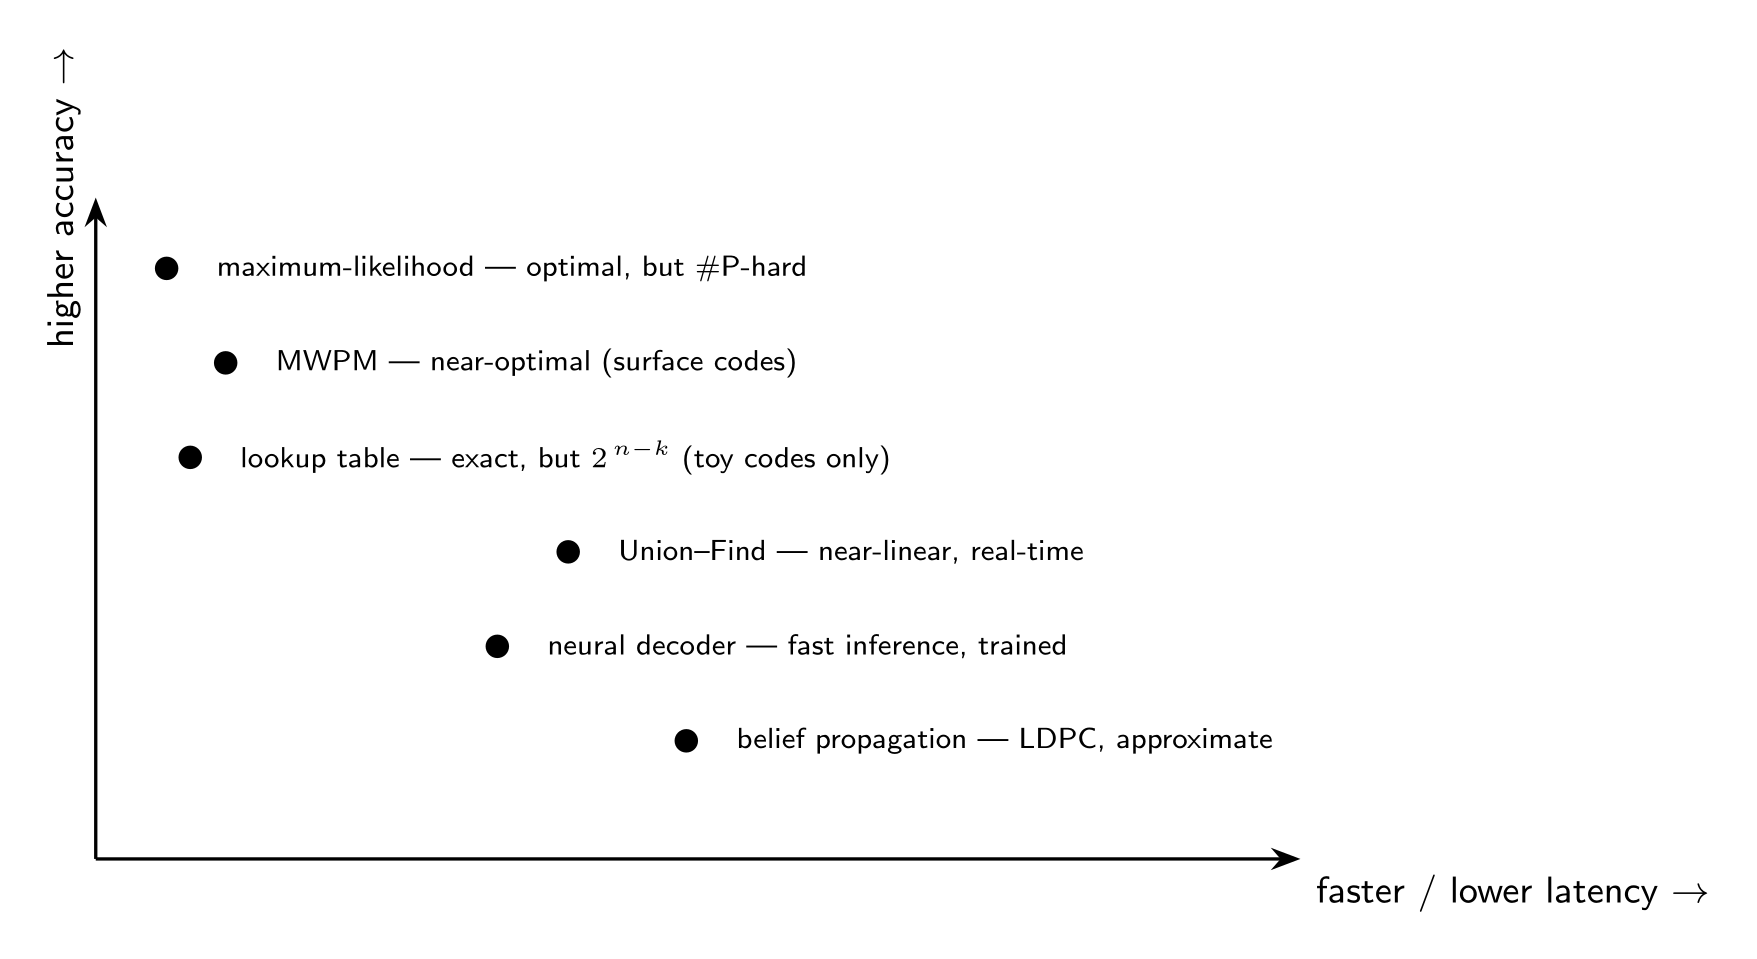</p>

Speed is not a luxury here: while the decoder thinks, the quantum computer sits idle and
*keeps* decohering, so a fast-but-approximate decoder often beats a slow optimal one in
practice. (You'll see this latency pressure again in **Lab 21**.)

<b>Feel the blow-up.</b> Write <code>lookup_size(n, k)</code> = the number of syndromes a lookup
decoder must store, and print it for a few codes. Notice where the table stops fitting in the
universe.

In [ ]:
def lookup_size(n, k):
    "Number of distinct syndromes (lookup-table entries) for an [[n,k]] code."
    # your code here
    ???

codes = {"3-qubit rep": (3, 1), "Steane": (7, 1),
         "surface d=11": (121, 1), "surface d=27": (729, 1)}
for name, (n, k) in codes.items():
    print(f"{name:14s}  n={n:3d}, k={k}:  2^{n-k} = {lookup_size(n, k):.2e} entries")

## 4. Correcting live — and measuring it for real

Time to stop reasoning about probabilities and **let the hardware tell us**. From here on,
every logical error rate in this lab comes from running an actual circuit under a Qiskit
**noise model** and counting how often the logical bit comes out wrong. Three new ingredients:

1. **A noise model.** Instead of *assuming* an error probability, we attach a real error
   channel to the qubits and let the simulator roll the dice. We mark each data qubit with an
   identity gate <code>id</code> and tell Qiskit "every <code>id</code> suffers an $X$ error
   with probability $p$." That's a `NoiseModel`.
2. **Active correction (a _dynamic circuit_).** We measure the syndrome **mid-circuit**, then
   apply the recovery $X$ **conditioned on the outcome**, right there in the circuit, with
   `with qc.if_test(...)`. The machine fixes itself before we ever read the data.
3. **An empirical rate.** Run many shots; the logical error rate is just the fraction of shots
   whose decoded logical bit is wrong.

<b>Build the noise channels and the baseline.</b> You'll write three short pieces here. The
4-outcome <code>biased_noise</code> channel (for §10) and the <code>logical_error_rate</code>
harness are provided — read them, you'll lean on both throughout.

1. <code>bitflip_noise(p)</code> — make a <code>NoiseModel()</code>, then call
   <code>add_all_qubit_quantum_error(pauli_error([("X", p), ("I", 1 - p)]), ["id"])</code> on it
   so every <code>id</code> marker suffers a Pauli-$X$ with probability $p$, and <code>return</code> it.
2. <code>phase_noise(p)</code> — exactly the same, but a $Z$ error instead of $X$. You'll need it in §6.
3. <code>bare_error(...)</code> — the unprotected qubit that the codes must *beat*. The baseline is
   a circuit too: on the single data qubit, **(a)** if <code>basis=="X"</code> apply <code>H</code>;
   **(b)** place one <code>id</code> noise marker; **(c)** if <code>basis=="X"</code> apply
   <code>H</code> again (so a $Z$ error shows up as a flip in the $X$ basis); **(d)** measure it;
   **(e)** <code>return logical_error_rate(qc, noise_model, lambda m: m == "1", shots)</code>.

In [ ]:
def bitflip_noise(p):
    "NoiseModel: every `id` marker suffers an X error with probability p."
    # your code here
    ???

def phase_noise(p):
    "NoiseModel: every `id` marker suffers a Z (phase) error with probability p."
    # your code here
    ???

def biased_noise(pX, pZ):                            # provided
    "Independent X (prob pX) and Z (prob pZ) on every `id` marker."
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(pauli_error(
        [("I", (1-pX)*(1-pZ)), ("X", pX*(1-pZ)), ("Z", (1-pX)*pZ), ("Y", pX*pZ)]), ["id"])
    return nm

def logical_error_rate(circuit, noise_model, fail, shots=8000):     # provided
    "Run `circuit` under `noise_model`; fail(data_bits)->True counts one logical error."
    counts = sim.run(circuit, noise_model=noise_model, shots=shots).result().get_counts()
    return sum(n for key, n in counts.items() if fail(key.split()[0])) / shots

def bare_error(noise_model, basis="Z", shots=8000):
    "One unprotected qubit through the same noise — the baseline to beat."
    q = QuantumRegister(1, "d"); c = ClassicalRegister(1, "m")
    qc = QuantumCircuit(q, c)
    # your code here
    ???

print("bare qubit under bitflip_noise(0.1):", round(bare_error(bitflip_noise(0.1)), 3), "(expect ~0.1)")

<b>Build the full QEC cycle — and decide what "failure" means.</b> Two functions here:
<code>build_bitflip_code</code> assembles the circuit, and <code>bitflip_code</code> runs it and
returns the logical error rate. The registers, encoding, noise markers, basis change and final
measurement are provided. In <code>build_bitflip_code</code>, after the noise markers:

1. **Extract the syndrome** onto the two ancillas, just as in §3 — but now the CNOTs land on the
   ancilla *register* qubits <code>a[0]</code> and <code>a[1]</code> ($A=Z_0Z_1\to a_0$,
   $B=Z_1Z_2\to a_1$) — then measure each ancilla onto its syndrome bit (<code>cs[0]</code>, <code>cs[1]</code>).
2. **Correct live.** The integer <code>value</code> packs the syndrome as $A + 2B$, so
   $(1,0)\!\to\!1$, $(1,1)\!\to\!3$, $(0,1)\!\to\!2$. For each, conditionally apply the matching
   $X$ with <code>with qc.if_test((cs, value)): qc.x(d[...])</code> — flip qubit&nbsp;0 on
   value&nbsp;1, qubit&nbsp;1 on value&nbsp;3, qubit&nbsp;2 on value&nbsp;2.

Then in <code>bitflip_code</code>, define <code>fail(m)</code> — *when did the recovered 3-bit
readout&nbsp;<code>m</code> come out wrong?* This is the decoder for the **final readout**: for
<code>logical="0"</code> decode by **majority** (wrong if **two or more** bits are 1); for
<code>logical="+"</code> a phase error shows up as **odd parity** (wrong if an **odd** number of
bits are 1). <code>logical="+"</code> prepares and reads $|+\rangle_L$ so you can reuse this for
phase noise later.

In [ ]:
def build_bitflip_code(logical="0"):
    "Build the 3-qubit QEC cycle: encode, noise markers, syndrome, live correction, readout."
    d = QuantumRegister(3, "d"); a = QuantumRegister(2, "a")
    cs = ClassicalRegister(2, "s"); cm = ClassicalRegister(3, "m")
    qc = QuantumCircuit(d, a, cs, cm)
    if logical == "+":                      # |+>_L = GHZ
        qc.h(d[0]); qc.cx(d[0], d[1]); qc.cx(d[0], d[2])
    for q in range(3): qc.id(d[q])          # <-- where the noise strikes
    qc.barrier()
    # your code here
    ???
    if logical == "+":
        for q in range(3): qc.h(d[q])       # read |+>_L in the X basis
    for q in range(3): qc.measure(d[q], cm[q])
    return qc

def bitflip_code(noise_model, logical="0", shots=8000):     # run it, return the logical error rate
    # fail(m): did the recovered 3-bit readout m decode to the WRONG logical value?
    # your code here
    ???
    return logical_error_rate(build_bitflip_code(logical), noise_model, fail, shots)

print("bit-flip code at p=0.1:", round(bitflip_code(bitflip_noise(0.1)), 3), "(expect ~0.028)")

<b>See the whole cycle.</b> This is the circuit you just built — read it left to right:
the <code>I</code> noise markers, the two parity checks onto ancillas $a_0,a_1$, the
mid-circuit ancilla measurements, the **conditional <code>If</code> boxes** that apply the
recovery $X$ *only* when the syndrome calls for it, and the final readout.

In [ ]:
build_bitflip_code().draw("mpl", fold=-1)

**✓ Check your circuit.** Three `id` markers, the two parity combs onto $a_0,a_1$, the two ancilla measurements, then the three conditional `If X` boxes (firing on syndrome values `0x1`, `0x3`, `0x2`), then the data readout. Yours should match this:

<p align="center">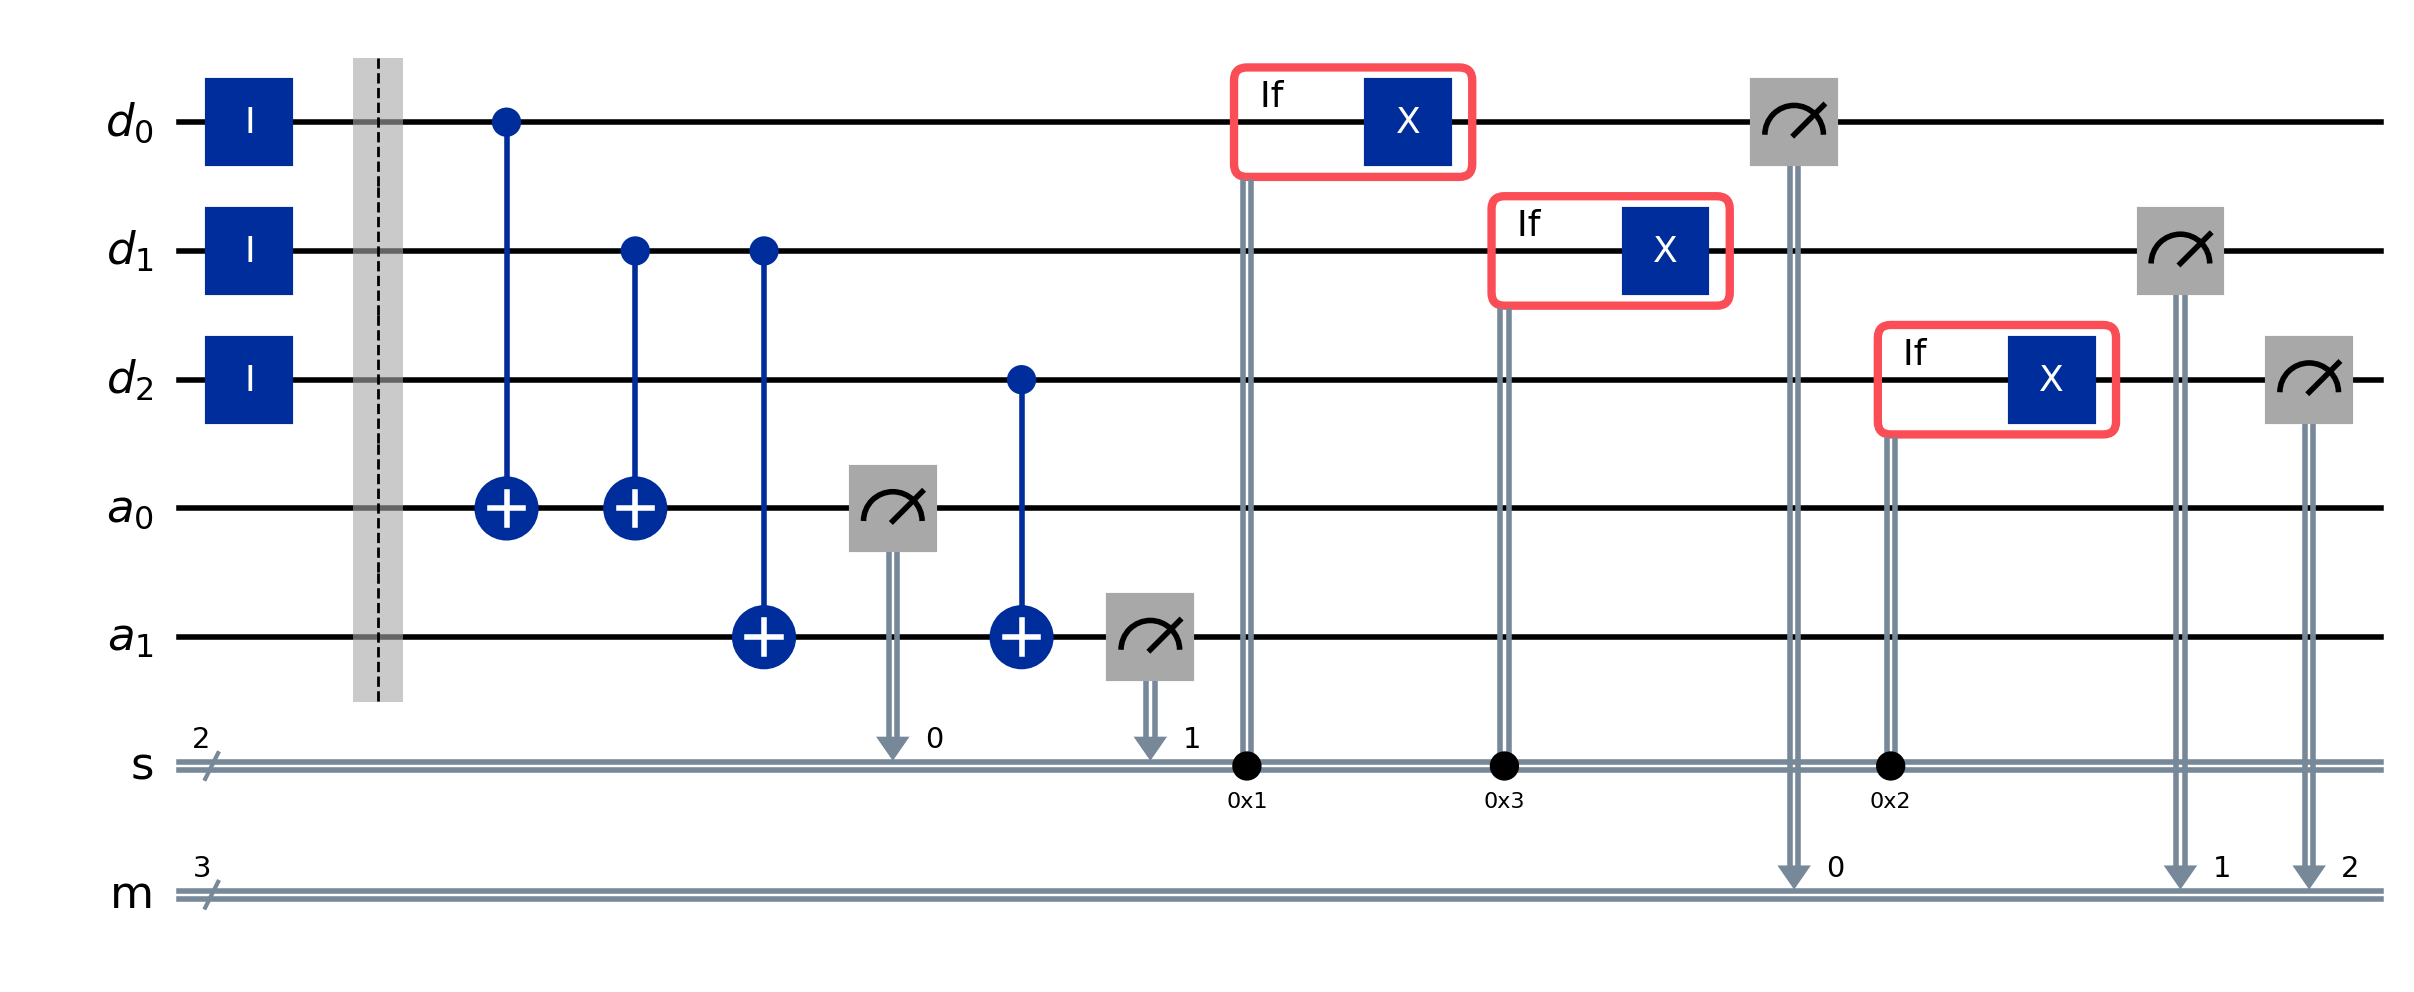</p>

<b>Find the threshold.</b> Sweep the physical error rate and measure both the bare
qubit and the coded qubit *from the circuits*. Build <code>ps</code>, <code>p_phys</code>
(bare) and <code>p_log3</code> (the code). The plot (provided) shows where the coded curve
crosses the bare line — the **break-even threshold**.

In [ ]:
# your code here
???
print("at p=0.10:  bare =", round(float(p_phys[2]), 3), " coded =", round(float(p_log3[2]), 3))

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(ps, p_phys, "k--", label="bare physical qubit")
plt.plot(ps, p_log3, "o-", color="tab:orange", ms=4, label="3-qubit code (logical)")
plt.axvline(0.5, color="gray", ls=":", lw=1)
plt.text(0.5, 0.05, " threshold\n p = 0.5", color="gray")
plt.xlabel("physical bit-flip probability  p"); plt.ylabel("error probability")
plt.title("Repetition code from real circuits: when does encoding help?")
plt.legend(); plt.tight_layout(); plt.show()

Below $p\approx0.5$ the coded qubit beats the bare one; above it, the extra qubits are a
liability. You measured that line from circuits — syndrome extraction, live correction, and all
— not from a formula.

## 5. Scaling up: a register of logical qubits

One protected qubit is a start, but a computation needs *many*. The natural next step is a
**register**: three logical qubits, **each with its own 3-qubit code and its own live
correction** — nine data qubits, six ancillas, three independent syndrome-and-correct blocks.

<b>Build the register.</b> Complete <code>register_code</code>: for each of the three blocks,
extract its 2-bit syndrome onto its ancilla pair and correct that block live (the same three
<code>if_test</code> rules as §4, on block $b$'s qubits $3b,3b{+}1,3b{+}2$). The whole register
fails if **any** block's majority comes out wrong.

In [ ]:
def register_code(noise_model, shots=8000):
    "Three logical qubits, each a live-corrected 3-qubit code (9 data + 6 ancilla)."
    d = QuantumRegister(9, "d"); a = QuantumRegister(6, "a")
    css = [ClassicalRegister(2, f"s{b}") for b in range(3)]
    cm = ClassicalRegister(9, "m")
    qc = QuantumCircuit(d, a, *css, cm)
    for q in range(9): qc.id(d[q])
    qc.barrier()
    # your code here
    ???
    for q in range(9): qc.measure(d[q], cm[q])
    def fail(m):
        bits = m[::-1]                       # bits[i] = qubit i
        return any(bits[3*k:3*k+3].count("1") >= 2 for k in range(3))
    return logical_error_rate(qc, noise_model, fail, shots)

print("register at p=0.1:", round(register_code(bitflip_noise(0.1)), 3), "(expect ~0.08)")

<b>Compare to bare hardware.</b> A bare register of three qubits is corrupted if *any*
of the three flips. Build <code>r_coded</code> (your register) and <code>r_bare</code> over
<code>ps</code> for the plot.

In [ ]:
# your code here
???
print("register at p=0.10:  bare =", round(float(r_bare[2]), 3), " coded =", round(float(r_coded[2]), 3))

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(ps, r_bare,  "k--", label="3 bare qubits")
plt.plot(ps, r_coded, "s-", color="tab:green", ms=4, label="3 logical qubits (9 physical)")
plt.axvline(0.5, color="gray", ls=":", lw=1)
plt.xlabel("physical bit-flip probability  p"); plt.ylabel("P(register corrupted)")
plt.title("A register of 3 logical qubits"); plt.legend(); plt.tight_layout(); plt.show()

Same threshold at $p=0.5$ — each block is still a $d=3$ code — but **below** it the
coded register pulls further ahead. That's the promise of QEC in one picture: add more qubits,
push the logical error down, *as long as you stay under threshold*.

## 6. The blind spot

So far, every error has been a bit-flip $X$. But a qubit has another way to go wrong: a
**phase flip** $Z$, which leaves $|0\rangle$ alone and sends $|1\rangle\to-|1\rangle$. Watch
what it does to a logical state held in the $X$ basis.

Take $|+\rangle_L=\tfrac{1}{\sqrt2}(|000\rangle+|111\rangle)$ (a GHZ state). A single $Z$ on
**any** of the three qubits flips it to $|-\rangle_L$:

<p align="center"><img alt="a single Z flips |+>_L to |->_L while the syndrome stays silent" width="560" src="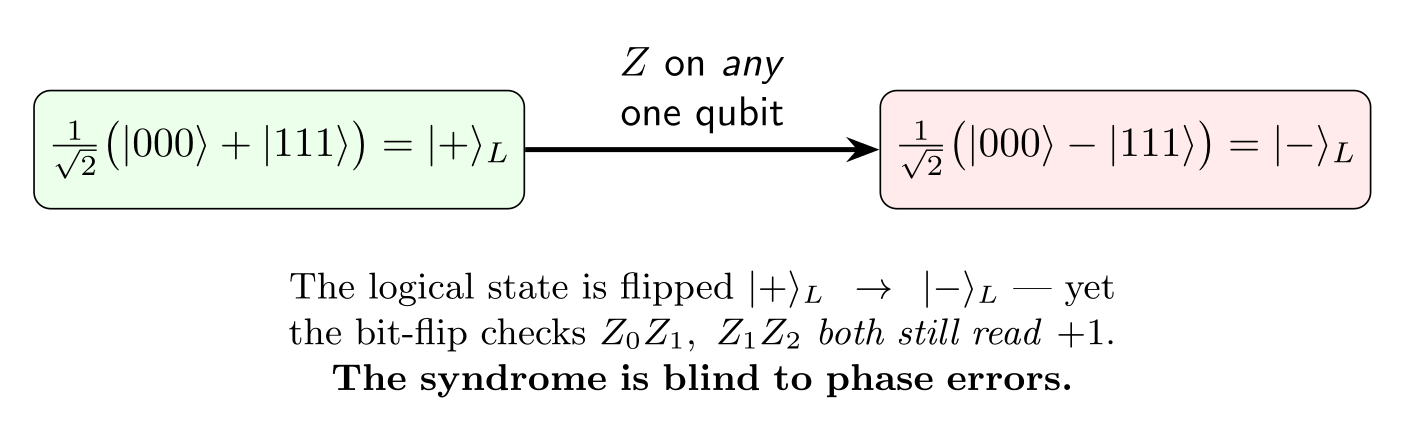"></p>

This is a genuine **logical error** — yet the bit-flip checks $Z_0Z_1,\,Z_1Z_2$ commute with
$Z$ and so read $(0,0)$ no matter where the phase flip landed. The code is **blind** to it.

<b>First, confirm the logical state.</b> Build $|+\rangle_L$ and check the logical
$\bar X = X_0X_1X_2$ reads $+1$.

In [ ]:
ghz = QuantumCircuit(3)
ghz.h(0)
encode_bitflip(ghz)
xbar = Statevector(ghz).expectation_value(Pauli("XXX")).real
print(f"<Xbar = X0 X1 X2> on |+>_L  =  {xbar:+.2f}   (expect +1)")

<b>Now measure the damage — from the circuit.</b> Your <code>bitflip_code</code> already
takes a <code>logical</code> argument: call it with <code>logical="+"</code> and a
<code>phase_noise</code> model. The active correction will dutifully fix bit-flips that aren't
there and do **nothing** about the phase flips. Build <code>p_phase</code> (the coded phase
error) and <code>ph_bare</code> (a bare qubit in the $X$ basis) over <code>ps</code>.

In [ ]:
# your code here
???
print("phase error at p=0.10:  bare =", round(float(ph_bare[2]), 3),
      " coded =", round(float(p_phase[2]), 3))

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(ps, ph_bare, "k--", label="bare qubit (phase)")
plt.plot(ps, p_phase, "^-", color="tab:red", ms=4, label="bit-flip code (phase)")
plt.xlabel("physical phase-flip probability  p"); plt.ylabel("logical phase-error probability")
plt.title("The bit-flip code makes phase errors WORSE"); plt.legend(); plt.tight_layout(); plt.show()

The red curve sits **above** the bare line everywhere: protecting against $X$ left us
*more* exposed to $Z$ (three qubits to dephase instead of one). A real qubit suffers both. We
need a code that corrects **bit flips and phase flips at once** — and that takes more than
repetition.

## 7. The Steane code: correcting everything

The **Steane [[7,1,3]] code** packs one logical qubit into seven physical ones and corrects
*any* single-qubit error — $X$, $Z$, or both. The trick (a **CSS** code) is to run **two**
sets of parity checks at once: three that catch bit flips and three that catch phase flips,
built from the classical **Hamming(7,4,3)** code. Its structure is the famous three-circle
picture, where each circle is one parity check:

<p align="center">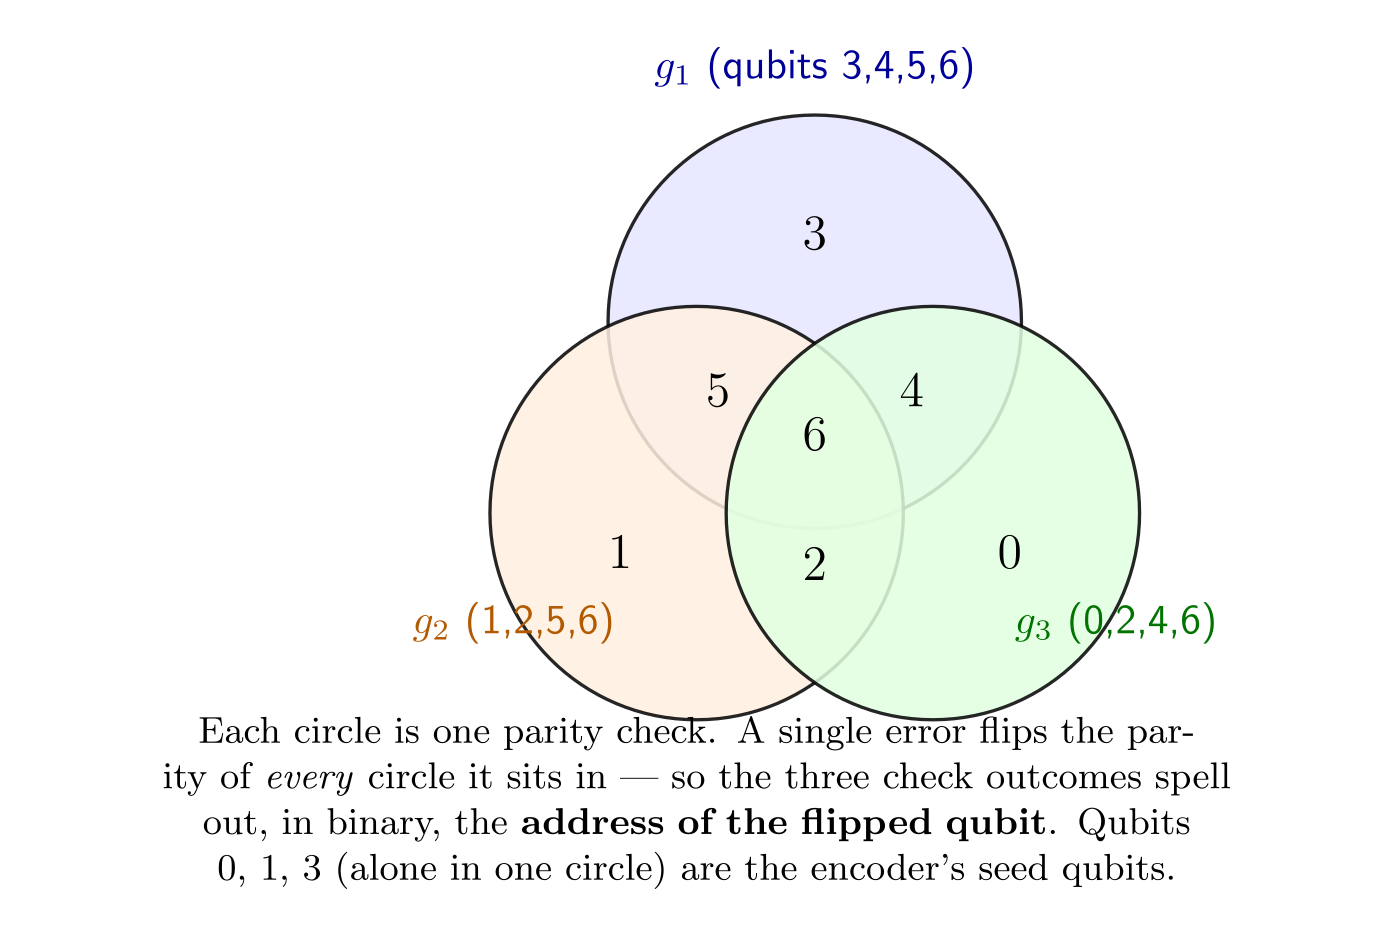</p>

Each circle is a stabilizer generator. A single error flips the parity of every circle it
sits in, so the three outcomes literally spell out, **in binary, the address of the broken
qubit** — Hamming's beautiful idea. The same picture works for $X$ checks and $Z$ checks
because the code is **self-dual**, which is why it handles both error types symmetrically.

<b>Build the encoder for $|0\rangle_L$.</b> The seeds are already placed: <code>H</code> on
qubits 0, 1, 3 (the three "alone in one circle" qubits). Complete the three generators by
spreading each seed onto the rest of its circle with CNOTs:

* $g_1$ — qubit 3 onto 4, 5, 6
* $g_2$ — qubit 1 onto 2, 5, 6
* $g_3$ — qubit 0 onto 2, 4, 6

The cell checks all six stabilizers and the logical $\bar Z=Z^{\otimes 7}$ read $+1$.

In [ ]:
def steane_encode_zero(qc, d=None):
    "Prepare logical |0>_L of the Steane [[7,1,3]] code on wires 0..6 (or register d)."
    w = (lambda i: i) if d is None else (lambda i: d[i])
    qc.h([w(0), w(1), w(3)])             # seed qubits (one per parity circle)
    # your code here
    ???

qc = QuantumCircuit(7)
steane_encode_zero(qc)
sv = Statevector(qc)

gens = [{3, 4, 5, 6}, {1, 2, 5, 6}, {0, 2, 4, 6}]
def pauli_on(support, P):                # Qiskit Pauli label runs q6..q0
    return Pauli("".join(P if q in support else "I" for q in range(6, -1, -1)))
stabs = [pauli_on(g, "X") for g in gens] + [pauli_on(g, "Z") for g in gens]
print("all six stabilizers = +1 :",
      all(abs(sv.expectation_value(g).real - 1) < 1e-9 for g in stabs))
print("logical Zbar = Z^7      = ", round(sv.expectation_value(Pauli("Z"*7)).real, 3))

Here is the seven-qubit encoder — denser than the repetition code, but the same idea of fanning structured entanglement across the block.

In [ ]:
qc = QuantumCircuit(7)
steane_encode_zero(qc)
qc.draw("mpl")

**✓ Check your circuit.** Hadamards on the three seeds (0, 1, 3), then each seed fanned out by three CNOTs: $g_1$ from qubit 3 onto 4,5,6; $g_2$ from qubit 1 onto 2,5,6; $g_3$ from qubit 0 onto 2,4,6. Yours should match this:

<p align="center"><img alt="Steane |0>_L encoder reference circuit" width="560" src="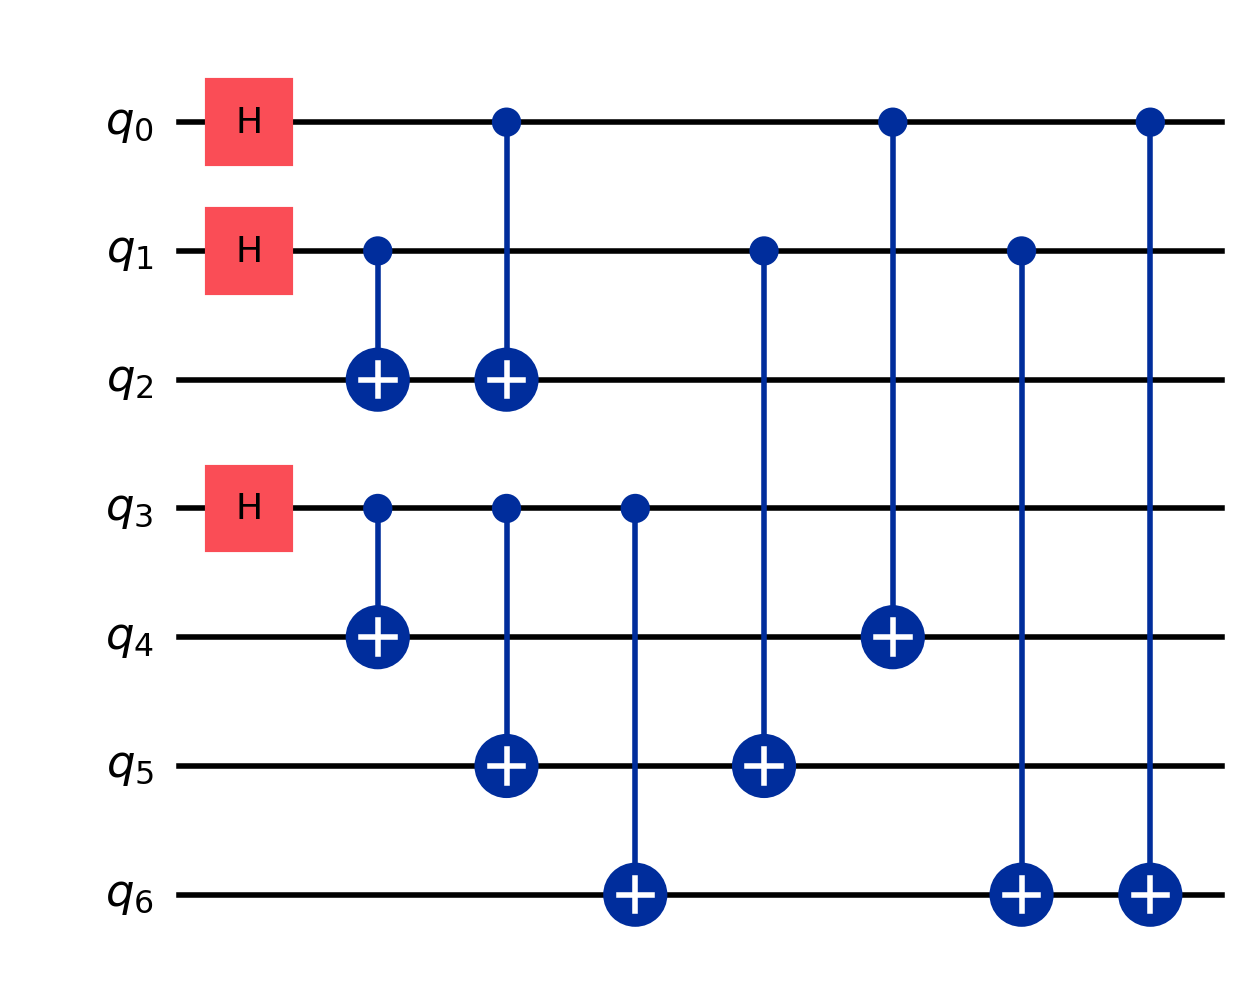"></p>

## 8. Steane's two thresholds — from the circuit

Now run the **full** Steane cycle. Because it's a CSS code we extract **two** kinds of
syndrome: three $Z$-type stabilizers (CNOTs *data → ancilla*) that locate **$X$ errors**, and
three $X$-type stabilizers (Hadamard the ancilla, CNOTs *ancilla → data*, Hadamard back) that
locate **$Z$ errors**. Each 3-bit syndrome is, by Hamming's trick, the binary **address** of
the broken qubit — so we correct with an $X$ (or a $Z$) on that one qubit, **live**.

<b>Build the full QEC cycle.</b> In <code>build_steane_full</code>, complete (i) the two
stabilizer read-outs and (ii) the live corrections — apply $X$ to the qubit the $Z$-syndrome
(<code>csz</code>) addresses, and $Z$ to the qubit the $X$-syndrome (<code>csx</code>)
addresses. The address map <code>col</code> and the encoder are provided. A distance-3 code
corrects **one** error and miscorrects most **pairs**, so expect a steeper curve (leading
$\sim\binom{7}{2}p^2 = 21p^2$) and therefore a **lower** threshold than repetition — but one
that now covers *both* error types.

In [ ]:
H = np.array([[0, 0, 0, 1, 1, 1, 1],
              [0, 1, 1, 0, 0, 1, 1],
              [1, 0, 1, 0, 1, 0, 1]])
col = {tuple(H[:, j]): j for j in range(7)}     # 3-bit syndrome -> qubit address

def build_steane_full(logical="0"):
    "Build the full Steane QEC cycle: all six stabilizers, live X and Z correction."
    d = QuantumRegister(7, "d"); ax = QuantumRegister(3, "ax"); az = QuantumRegister(3, "az")
    csx = ClassicalRegister(3, "sx"); csz = ClassicalRegister(3, "sz"); cm = ClassicalRegister(7, "m")
    qc = QuantumCircuit(d, ax, az, csx, csz, cm)
    steane_encode_zero(qc, d)
    if logical == "+":
        for q in range(7): qc.h(d[q])
    for q in range(7): qc.id(d[q])              # noise location
    qc.barrier()
    # your code here
    ???
    if logical == "+":
        for q in range(7): qc.h(d[q])
    for q in range(7): qc.measure(d[q], cm[q])
    return qc

def steane_full(noise_model, logical="0", shots=8000):     # provided: run it, return the rate
    return logical_error_rate(build_steane_full(logical), noise_model, lambda m: m.count("1") % 2 == 1, shots)

print("Steane at p=0.05:  X-noise =", round(steane_full(bitflip_noise(0.05)), 3),
      " Z-noise =", round(steane_full(phase_noise(0.05), logical="+"), 3), "(both ~0.04)")

<b>See the full cycle.</b> It's the §4 pattern scaled up: encode, noise, then **six**
stabilizer read-outs — three $Z$-type (CNOTs *data→ancilla*) that locate bit-flips, and three
$X$-type (note the Hadamard sandwich, CNOTs *ancilla→data*) that locate phase-flips — followed
by conditional <code>If</code> corrections ($X$ in red, $Z$ in cyan) addressed by the
syndromes. It's a wide circuit; **scroll right** to follow it end to end.

In [ ]:
build_steane_full().draw("mpl", fold=-1)

<b>Measure both thresholds.</b> Sweep $X$ noise on $|0\rangle_L$ and $Z$ noise on
$|+\rangle_L$. Build <code>ps_s</code>, <code>steane_X</code>, <code>steane_Z</code>; the plot
overlays a bare qubit and the repetition code so you can compare the thresholds.

In [ ]:
# your code here
???
rep_X = np.array([bitflip_code(bitflip_noise(x)) for x in ps_s])
print("Steane X vs Z at p=0.05:", round(float(steane_X[3]), 3), round(float(steane_Z[3]), 3))

In [ ]:
plt.figure(figsize=(6.3, 4.3))
plt.plot(ps_s, ps_s,     "k--", label="bare qubit")
plt.plot(ps_s, steane_X, "o-", color="tab:purple", ms=4, label="Steane, bit flips")
plt.plot(ps_s, steane_Z, "D-", color="tab:blue",   ms=4, label="Steane, phase flips")
plt.plot(ps_s, rep_X,    "s-", color="tab:orange",  ms=4, label="3-qubit code (bit only)")
plt.xlabel("physical error probability  p"); plt.ylabel("logical error probability")
plt.title("Steane corrects everything — at a lower threshold")
plt.legend(); plt.tight_layout(); plt.show()

Both Steane curves (bit and phase) lie on top of each other — that's **self-duality** —
and both dip below the bare line up to $p\approx0.06$. The repetition code tolerates a far
higher rate (threshold $0.5$) but only for *one* error type; throw phase noise at it and it
fails outright (§6). **Universality costs threshold.**

---

# Part II — open exploration

Everything up to here had a single right answer. **The rest of the lab does not.** In each of
the next three sections you'll be handed a *different* piece — a different code distance, a
different noise bias, a different decoder — work it out by **running your circuits under noise**,
and **post your result on the whiteboard we know and love in the crossover**. No one can see the whole picture alone; the
class assembles it together. Expect to disagree with the group next to you, and expect a few
surprises about where those disagreements resolve.

Each section gives you the experiment to build for *your* piece, then a **reference cell** that
runs every piece at once — that's the assembled picture the whiteboard should reproduce.

## 9. The distance ladder

You found the $d=3$ code beats a bare qubit below $p=0.5$. Does piling on *more* qubits help
*more*? **Your assignment: one odd distance $d$ from $\{3,5,7,9,11\}$** (your instructor gives
each group one).

For the repetition code there's no need for ancillas: encode $|0\rangle_L=|0\ldots0\rangle$,
let the noise hit, **measure all $d$ qubits, and majority-vote the shots** — that *is* the
decoder. <b>Write</b> <code>rep_distance(d, noise_model, shots)</code> returning the logical
error rate, and confirm a couple of distances against the bare line. <b>Tape your curve to the whiteboard.</b>

In [ ]:
def rep_distance(d, noise_model, shots=12000):
    "Distance-d repetition code (logical |0>): noise, measure all d, majority-vote the shots."
    data = QuantumRegister(d, "d"); cm = ClassicalRegister(d, "m")
    qc = QuantumCircuit(data, cm)
    for q in range(d): qc.id(data[q])
    for q in range(d): qc.measure(data[q], cm[q])
    # your code here
    ???

MY_D = 5                       # <-- your assigned distance
print(f"d={MY_D} at p=0.1: code = {rep_distance(MY_D, bitflip_noise(0.1)):.4f}   bare = 0.1")

In [ ]:
# Reference: the overlaid plot the whole class assembles on the whiteboard.
ps_d = np.linspace(0.0, 0.6, 13)
plt.figure(figsize=(6.4, 4.4))
for d in [3, 5, 7, 9, 11]:
    plt.plot(ps_d, [rep_distance(d, bitflip_noise(x)) for x in ps_d], "-", label=f"d = {d}")
plt.plot(ps_d, ps_d, "k--", lw=1, label="bare")
plt.axvline(0.5, color="gray", ls=":", lw=1)
plt.yscale("log"); plt.ylim(1e-4, 1)
plt.xlabel("physical bit-flip probability  p"); plt.ylabel("logical error (log scale)")
plt.title("Distance ladder: the threshold stays put, the slope steepens")
plt.legend(ncol=2); plt.tight_layout(); plt.show()

Every curve pivots at the **same** $p=0.5$ — adding qubits does *not* move the threshold.
What changes is the **slope** below it: each extra pair of qubits buys roughly another $3\times$
suppression. That's the threshold theorem in miniature — stay under threshold and you can push
the logical error as low as you like just by paying qubits. (Down near $10^{-4}$ the curves get
jagged: that's **shot noise** — too few failures in your sample. A real numerical-physics
lesson; the high-$d$ groups should bump `shots` up.)

## 10. Own a noise bias

Real hardware rarely flips ($X$) and dephases ($Z$) at the same rate. Hold the **total** budget
fixed at $p_{\text{tot}}=p_X+p_Z=0.08$ and define the **bias** $\eta = p_Z/p_X$. **Your
assignment: one bias $\eta$ from $\{0,\ 0.25,\ 0.5,\ 1,\ 2,\ 5,\ 10,\ \infty\}$.**

For your $\eta$, run three competitors under the same <code>biased_noise(pX, pZ)</code> — a
**bare** qubit, the **bit-flip code**, and **Steane** — and declare **which wins**. A logical
qubit can fail in *either* basis, so combine an $X$-basis run and a $Z$-basis run as
$1-(1-e_X)(1-e_Z)$. <b>Write</b> <code>rep_biased</code> and <code>steane_biased</code>, reusing
<code>bitflip_code</code> / <code>steane_full</code> with <code>logical="0"</code> (catches $X$)
and <code>logical="+"</code> (catches $Z$). Post your $(\eta,\text{ winner})$ to the whiteboard.

In [ ]:
def split(eta, p_tot=0.08):
    "Split the budget into (pX, pZ) for bias eta = pZ/pX  (use eta=1e9 for 'infinity')."
    pX = p_tot / (1 + eta)
    return pX, p_tot - pX

def rep_biased(pX, pZ, shots=6000):
    "Bit-flip code under biased noise: corrupted if it fails in X OR Z basis."
    # your code here
    ???

def steane_biased(pX, pZ, shots=6000):
    "Steane under biased noise: corrupted if it fails in X OR Z basis."
    # your code here
    ???

MY_ETA = 1.0                   # <-- your assigned bias
pX, pZ = split(MY_ETA)
bare = 1 - (1 - bare_error(biased_noise(pX, pZ))) * (1 - bare_error(biased_noise(pX, pZ), basis="X"))
print(f"eta={MY_ETA}:  bare={bare:.3f}  bit-flip={rep_biased(pX, pZ):.3f}  Steane={steane_biased(pX, pZ):.3f}")

In [ ]:
# Reference: the 'which code wins' board the class assembles.
for eta in [0, 0.25, 0.5, 1, 2, 5, 10, 1e9]:
    pX, pZ = split(eta)
    nm = biased_noise(pX, pZ)
    b = 1 - (1 - bare_error(nm)) * (1 - bare_error(nm, basis="X"))
    r, s = rep_biased(pX, pZ), steane_biased(pX, pZ)
    winner = ["bare", "bit-flip", "Steane"][int(np.argmin([b, r, s]))]
    et = "inf" if eta > 1e8 else f"{eta:g}"
    print(f"  eta={et:>4}:  bare={b:.3f}  bit-flip={r:.3f}  Steane={s:.3f}   -> {winner}")

Three different winners. A group at $\eta=0$ swears by the repetition code; a group at
$\eta=2$ swears by Steane; a group out at $\eta=\infty$ finds the budget so concentrated in
phase that — at this error rate — *neither* code beats leaving the qubit bare. **There is no
universally best code, only the best code for your noise.** This is exactly why hardware-aware
**biased-noise codes** are an active research area.

## 11. Decoder bake-off

Every threshold so far used the *obvious* correction. But the code and the decoder are separate
choices. Fix the code (the $d=3$ bit-flip code) and change only the **correction rule applied in
the circuit** — then read the logical qubit off a *single* data wire (qubit 0), as you would in a
real computation that keeps running after correction.

**Your assignment: one decoding rule**, written as a list of <code>(syndrome_value, qubit)</code>
corrections:
* **good** — `[(1,0),(3,1),(2,2)]` (flip the addressed qubit),
* **lazy** — `[]` (don't bother correcting),
* **bad** — flip the *wrong* qubits,
* or invent your own.

<b>Build</b> <code>bitflip_decoder(table, noise_model)</code> from scratch this time — the
registers, noise markers and final readout are provided, the rest is yours:

1. **Extract the syndrome** onto the two ancillas exactly as in §4 — the four CNOTs
   ($Z_0Z_1\to a_0$, $Z_1Z_2\to a_1$), then measure each ancilla onto <code>cs[0]</code>, <code>cs[1]</code>.
2. **Apply your decoder:** for each <code>(value, qubit)</code> pair in <code>table</code>, add
   <code>with qc.if_test((cs, value)): qc.x(d[qubit])</code>.

The logical bit is then read off qubit&nbsp;0 (provided) — as it would be in a computation that
keeps running after correction. Tape your curve to the whiteboard.

In [ ]:
def bitflip_decoder(table, noise_model, shots=8000):
    "3-qubit code, custom correction `table`; logical bit read from qubit 0 after correction."
    d = QuantumRegister(3, "d"); a = QuantumRegister(2, "a")
    cs = ClassicalRegister(2, "s"); cm = ClassicalRegister(1, "m")
    qc = QuantumCircuit(d, a, cs, cm)
    for q in range(3): qc.id(d[q])
    qc.barrier()
    # your code here
    ???
    qc.measure(d[0], cm[0])
    return logical_error_rate(qc, noise_model, lambda m: m == "1", shots)

MY_TABLE = [(1, 0), (3, 1), (2, 2)]      # <-- your decoder
print("my decoder at p=0.1:", round(bitflip_decoder(MY_TABLE, bitflip_noise(0.1)), 3))

In [ ]:
# Reference: the decoder leaderboard the class assembles (code & noise identical for all).
decoders = {
    "good":  [(1, 0), (3, 1), (2, 2)],
    "lazy":  [],
    "bad":   [(1, 1), (3, 0), (2, 0)],
}
ps_k = np.linspace(0.0, 0.5, 11)
plt.figure(figsize=(6.2, 4))
for name, table in decoders.items():
    plt.plot(ps_k, [bitflip_decoder(table, bitflip_noise(x)) for x in ps_k], "-", label=name)
plt.plot(ps_k, ps_k, "k--", lw=1, label="bare")
plt.xlabel("physical bit-flip probability  p"); plt.ylabel("logical error (read from qubit 0)")
plt.title("Same code, same noise — only the decoder changes")
plt.legend(); plt.tight_layout(); plt.show()

The *same* code spans the whole picture: **lazy** throws the redundancy away and lands
right on the bare line; the **bad** decoder is worse than useless; only **good** beats the bare
qubit. **A code is only as good as its decoder** — which is why decoding (the §3 aside) is a
research field, not a footnote.

## Wrap-up

You built two quantum codes **as real circuits** and measured — from noisy simulation, not
formulas — exactly what they buy:

| code | physical qubits | corrects | (pseudo)threshold |
|:--|:--:|:--|:--:|
| 3-qubit repetition | 3 | bit flips **only** | $p \approx 0.5$ |
| Steane [[7,1,3]] | 7 | **any** single-qubit error | $p \approx 0.05\text{–}0.06$ |

The headline tension is right there in the table: the repetition code tolerates a huge error
rate but guards only one direction, while Steane guards *every* direction at the price of a
much lower threshold. **Universality costs threshold** — the same flavor of trade-off you met
when synthesis error fought hardware error back in **Lab 9**.

And the open explorations drove home that there is rarely a single "best": the right
**distance**, **decoder**, and **code** all depend on your error budget and the *shape* of your
noise. Quantum error correction is a **design space**, not a recipe.

Two ideas carry forward:

* **Stay under threshold and you win as much as you like.** Below $p_{\text{th}}$, making the
  code bigger (more repetition, larger distance, concatenation) drives the logical error
  *arbitrarily* low. That is the **threshold theorem**, and it's why scalable quantum
  computing is possible at all.
* **We gave the error correction an easy ride.** The noise hit only the *data* qubits — our
  syndrome-extraction gates, ancillas, and corrections were all perfect. On real hardware those
  are noisy too, and the decoder must run *fast* (the latency you saw in §3), which is why the
  favored codes today are **surface codes** with thresholds near $1\%$.

**Lab 21** picks up exactly there: what it costs to compute *fault-tolerantly* once even the
error-correction machinery is itself imperfect.